In [12]:
# 1. Mount Google Drive
from google.colab import drive
import pandas as pd
import os

# This will prompt you to click a link and authorize Colab to access your Drive
drive.mount('/content/drive')

# 2. Define Base Path
# Assuming 'DSProjectDatasets' is in the root of your Google Drive
BASE_PATH = '/content/drive/MyDrive/DSProjectDatasets/'

# 3. Define Subfolder Paths (Adjust these if your folder names differ slightly)
CLICKBAIT_DIR = os.path.join(BASE_PATH, 'Clickbait')
FAKENEWS_DIR = os.path.join(BASE_PATH, 'FakeNewsNet')
FEVER_DIR = os.path.join(BASE_PATH, 'FEVER')
FINANCE_DIR = os.path.join(BASE_PATH, 'FinancialPhrase')

# ==========================================
# 4. LOAD THE DATASETS
# ==========================================

print("Loading datasets...")

# --- CLICKBAIT DATASET (Standard CSV) ---
try:
    df_clickbait = pd.read_csv(os.path.join(CLICKBAIT_DIR, 'clickbait_data.csv'))
    print(f"✅ Clickbait loaded: {df_clickbait.shape}")
except Exception as e:
    print(f"❌ Error loading Clickbait: {e}")

# --- FAKENEWSNET (Standard CSVs) ---
try:
    df_gossip_real = pd.read_csv(os.path.join(FAKENEWS_DIR, 'gossipcop_real.csv'))
    df_gossip_fake = pd.read_csv(os.path.join(FAKENEWS_DIR, 'gossipcop_fake.csv'))
    df_politi_real = pd.read_csv(os.path.join(FAKENEWS_DIR, 'politifact_real.csv'))
    df_politi_fake = pd.read_csv(os.path.join(FAKENEWS_DIR, 'politifact_fake.csv'))
    print(f"✅ FakeNewsNet loaded. Gossip Fake: {df_gossip_fake.shape}")
except Exception as e:
    print(f"❌ Error loading FakeNewsNet: {e}")

# --- FEVER (JSON Lines format) ---
# JSONL requires the lines=True parameter
try:
    df_fever_dev = pd.read_json(os.path.join(FEVER_DIR, 'shared_task_dev.jsonl'), lines=True)
    df_fever_train = pd.read_json(os.path.join(FEVER_DIR, 'train.jsonl'), lines=True)
    print(f"✅ FEVER loaded. Train shape: {df_fever_train.shape}")
except Exception as e:
    print(f"❌ Error loading FEVER: {e}")

# --- FINANCIAL PHRASEBANK (TXT with special separator) ---
# Financial Phrasebank is usually separated by '@' and requires 'latin-1' encoding
try:
    # Example loading just the 50Agree dataset
    df_fin_50 = pd.read_csv(
        os.path.join(FINANCE_DIR, 'Sentences_50Agree.txt'),
        sep='@',
        encoding='latin-1',
        names=['sentence', 'sentiment']
    )
    print(f"✅ Financial PhraseBank (50Agree) loaded: {df_fin_50.shape}")
except Exception as e:
    print(f"❌ Error loading Financial PhraseBank: {e}")

print("Data loading complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading datasets...
✅ Clickbait loaded: (32000, 2)
✅ FakeNewsNet loaded. Gossip Fake: (5323, 4)
✅ FEVER loaded. Train shape: (145449, 5)
✅ Financial PhraseBank (50Agree) loaded: (4846, 2)
Data loading complete.


In [ ]:
# ==========================================
# PHASE 2: STEP 1 — SCHEMA INSPECTION
# ==========================================

print("--- Clickbait Columns & Sample ---")
print(df_clickbait.columns.tolist())
print(df_clickbait.head(2), "\n")

print("--- FakeNewsNet (Gossipcop) Columns & Sample ---")
print(df_gossip_fake.columns.tolist())
print(df_gossip_fake.head(2), "\n")

print("--- FEVER Columns & Sample ---")
print(df_fever_train.columns.tolist())
print(df_fever_train.head(2), "\n")

print("--- Financial PhraseBank Columns & Sample ---")
print(df_fin_50.columns.tolist())
print(df_fin_50.head(2), "\n")

--- Clickbait Columns & Sample ---
['headline', 'clickbait']
                                        headline  clickbait
0                             Should I Get Bings          1
1  Which TV Female Friend Group Do You Belong In          1 

--- FakeNewsNet (Gossipcop) Columns & Sample ---
['id', 'news_url', 'title', 'tweet_ids']
                     id                                           news_url  \
0  gossipcop-2493749932  www.dailymail.co.uk/tvshowbiz/article-5874213/...   
1  gossipcop-4580247171  hollywoodlife.com/2018/05/05/paris-jackson-car...   

                                               title  \
0  Did Miley Cyrus and Liam Hemsworth secretly ge...   
1  Paris Jackson & Cara Delevingne Enjoy Night Ou...   

                                           tweet_ids  
0  284329075902926848\t284332744559968256\t284335...  
1  992895508267130880\t992897935418503169\t992899...   

--- FEVER Columns & Sample ---
['id', 'verifiable', 'label', 'claim', 'evidence']
       id  ver

In [ ]:
# ==========================================
# PHASE 2: DATASET STANDARDIZATION & CLEANING
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split

print("Starting dataset standardization...")

processed_dfs = []

# 1. Process Clickbait Dataset
df_click_mod = pd.DataFrame({
    'text': df_clickbait['headline'],
    'label': df_clickbait['clickbait'],
    'source': 'clickbait'
})
processed_dfs.append(df_click_mod)
print(f"-> Standardized Clickbait: {df_click_mod.shape}")

# 2. Process FakeNewsNet Dataset (Combining all 4 files)
try:
    # Assign labels based on file origin
    df_gossip_fake['label'] = 1
    df_gossip_real['label'] = 0
    df_politi_fake['label'] = 1
    df_politi_real['label'] = 0

    fakenews_combined = pd.concat([df_gossip_fake, df_gossip_real, df_politi_fake, df_politi_real], ignore_index=True)

    df_fakenews_mod = pd.DataFrame({
        'text': fakenews_combined['title'],
        'label': fakenews_combined['label'],
        'source': 'fakenewsnet'
    })
    processed_dfs.append(df_fakenews_mod)
    print(f"-> Standardized FakeNewsNet: {df_fakenews_mod.shape}")
except NameError as e:
    print(f"⚠️ FakeNewsNet files missing from memory. Ensure all 4 DataFrames are loaded. Error: {e}")

# 3. Process FEVER Dataset
# Filtering out ambiguous 'NOT_ENOUGH_INFO' labels to keep the classification clean
df_fever_filtered = df_fever_train[df_fever_train['label'].isin(['SUPPORTS', 'REFUTES'])].copy()
fever_label_map = {'REFUTES': 1, 'SUPPORTS': 0} # Refutes implies a false/deceptive statement

df_fever_mod = pd.DataFrame({
    'text': df_fever_filtered['claim'],
    'label': df_fever_filtered['label'].map(fever_label_map),
    'source': 'fever'
})
processed_dfs.append(df_fever_mod)
print(f"-> Standardized FEVER: {df_fever_mod.shape}")

# 4. Process Financial PhraseBank Dataset
# This dataset represents credible, verified financial text, acting as a clean baseline
df_fin_mod = pd.DataFrame({
    'text': df_fin_50['sentence'],
    'label': 0,
    'source': 'financial_phrasebank'
})
processed_dfs.append(df_fin_mod)
print(f"-> Standardized Financial PhraseBank: {df_fin_mod.shape}")

# ==========================================
# 5. MASTER MERGE & PURGE
# ==========================================

# Combine all datasets into one master DataFrame
df_master = pd.concat(processed_dfs, ignore_index=True)

# Drop any potential null entries or explicit duplicates across sources
df_master.dropna(subset=['text', 'label'], inplace=True)
df_master.drop_duplicates(subset=['text'], inplace=True)

# Cast label to integer type
df_master['label'] = df_master['label'].astype(int)

print("\n=== Master Dataset Summary ===")
print(f"Total rows: {df_master.shape[0]}")
print(f"Class Distribution:\n{df_master['label'].value_counts(normalize=True) * 100}")
print(f"Source Breakdown:\n{df_master['source'].value_counts()}")

# Save intermediate progress to drive
OUTPUT_PATH = '/content/drive/MyDrive/DSProjectDatasets/master_cleaned_dataset.csv'
df_master.to_csv(OUTPUT_PATH, index=False)
print(f"\n✅ Cleaned Master Dataset saved successfully to: {OUTPUT_PATH}")

Starting dataset standardization...
-> Standardized Clickbait: (32000, 3)
-> Standardized FakeNewsNet: (23196, 3)
-> Standardized FEVER: (109810, 3)
-> Standardized Financial PhraseBank: (4846, 3)

=== Master Dataset Summary ===
Total rows: 160852
Class Distribution:
label
0    69.115709
1    30.884291
Name: proportion, dtype: float64
Source Breakdown:
source
fever                   102292
clickbait                32000
fakenewsnet              21722
financial_phrasebank      4838
Name: count, dtype: int64

✅ Cleaned Master Dataset saved successfully to: /content/drive/MyDrive/DSProjectDatasets/master_cleaned_dataset.csv


Step 1: Splitting dataset into Train and Test sets (80/20)...
Train size: 128681 | Test size: 32171

Step 2: Vectorizing text using TF-IDF...
✅ Text vectorization complete.

Step 3: Training Baseline Logistic Regression Model...
✅ Model training complete.

Step 4: Evaluating Baseline Model...

=== CLASSIFICATION REPORT ===
                        precision    recall  f1-score   support

 Authentic/Neutral (0)       0.79      0.95      0.86     22235
Manipulative/False (1)       0.79      0.44      0.57      9936

              accuracy                           0.79     32171
             macro avg       0.79      0.70      0.72     32171
          weighted avg       0.79      0.79      0.77     32171


Step 5: Generating Confusion Matrix...


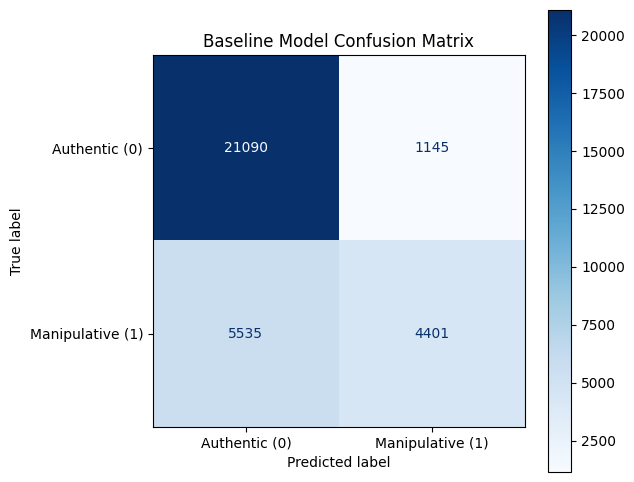

In [ ]:
# =====================================================================
# PHASE 2 (SPLIT) & PHASE 3 (BASELINE LOGISTIC REGRESSION)
# =====================================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Step 1: Splitting dataset into Train and Test sets (80/20)...")
# Stratify ensures the 70/30 class balance is perfectly preserved in both sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_master['text'],
    df_master['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_master['label']
)

print(f"Train size: {X_train_raw.shape[0]} | Test size: {X_test_raw.shape[0]}")

print("\nStep 2: Vectorizing text using TF-IDF...")
# max_features=10000 prevents Colab from running out of RAM while keeping high-value words
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train_raw)
X_test_tfidf = vectorizer.transform(X_test_raw)
print("✅ Text vectorization complete.")

print("\nStep 3: Training Baseline Logistic Regression Model...")
# liblinear solver is efficient for high-dimensional sparse matrices
baseline_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
baseline_model.fit(X_train_tfidf, y_train)
print("✅ Model training complete.")

# =====================================================================
# EVALUATION METRICS
# =====================================================================

print("\nStep 4: Evaluating Baseline Model...")
y_pred = baseline_model.predict(X_test_tfidf)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Authentic/Neutral (0)', 'Manipulative/False (1)']))

# Generate and plot confusion matrix
print("\nStep 5: Generating Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred, labels=baseline_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Authentic (0)', 'Manipulative (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Baseline Model Confusion Matrix')
plt.show()

In [ ]:
import random
import pandas as pd
from datasets import Dataset

# 1. Create a Synthetic Financial Scam Generator
scam_templates = [
    "Guaranteed {pct} monthly returns on {crypto} trading. No risk involved, DM me now!",
    "Want free money? Join my group to unlock hidden {crypto} secrets and make {cash} daily!",
    "Get rich quick with this passive income loop! {pct} payout assured today.",
    "Sign up here and deposit now to get a guaranteed {cash} bonus on your first trade!",
    "Absolute 100% risk-free returns on automated {crypto} investments. DM for details."
]

cryptos = ["crypto", "bitcoin", "forex", "solana", "meme coin", "options"]
percentages = ["20%", "50%", "100%", "500%", "10% daily"]
cashes = ["$1000", "$5000", "$10,000", "$200"]

synthetic_scams = []
for _ in range(1500):
    template = random.choice(scam_templates)
    filled = template.format(
        pct=random.choice(percentages),
        crypto=random.choice(cryptos),
        cash=random.choice(cashes)
    )
    synthetic_scams.append(filled)

# 2. Convert to DataFrame and Merge with Master Dataset
df_scams = pd.DataFrame({'text': synthetic_scams, 'label': 1, 'source': 'synthetic_financial_scams'})
df_new_master = pd.concat([df_master, df_scams], ignore_index=True).drop_duplicates(subset=['text'])

print(f"New dataset shape with targeted financial scam injection: {df_new_master.shape}")

# 3. Fast Re-Training / Fine-Tuning Step
# Run your Train/Test Split and your Phase 4 Hugging Face Trainer code again
# using this updated 'df_new_master' dataset.

New dataset shape with targeted financial scam injection: (160920, 3)


In [ ]:
# =====================================================================
# PHASE 4: DISTILBERT FINE-TUNING VIA HUGGING FACE (WITH SCAM FIX)
# =====================================================================

# 1. Install required modern transformer and optimization libraries
!pip install -U transformers datasets accelerate peft -q

import os
import random
import torch
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

# --- STEP 1: RE-LOAD AND AUGMENT MASTER DATASET ---
CLEANED_DATA_PATH = '/content/drive/MyDrive/DSProjectDatasets/master_cleaned_dataset.csv'

if os.path.exists(CLEANED_DATA_PATH):
    print("Loading cleaned master dataset...")
    df_master = pd.read_csv(CLEANED_DATA_PATH)

    # --- ADVERSARIAL DATA AUGMENTATION PATCH ---
    print("Injecting targeted synthetic financial scams to eliminate model bias...")
    scam_templates = [
        "Guaranteed {pct} monthly returns on {crypto} trading. No risk involved, DM me now!",
        "Want free money? Join my group to unlock hidden {crypto} secrets and make {cash} daily!",
        "Get rich quick with this passive income loop! {pct} payout assured today.",
        "Sign up here and deposit now to get a guaranteed {cash} bonus on your first trade!",
        "Absolute 100% risk-free returns on automated {crypto} investments. DM for details.",
        "Turn {cash} into massive wealth with my automated {crypto} signals. 100% success rate!",
        "Learn how I make {cash} every week on passive crypto income. Click link to join!",
        "Crypto market secrets revealed: build financial freedom with {pct} gains guaranteed!"
    ]

    cryptos = ["crypto", "bitcoin", "forex", "solana", "meme coin", "options trading", "altcoins"]
    percentages = ["20%", "50%", "100%", "500%", "10% daily", "300% weekly"]
    cashes = ["$1000", "$5000", "$10,000", "$500", "$2500"]

    synthetic_scams = []
    for _ in range(1500):
        template = random.choice(scam_templates)
        filled = template.format(
            pct=random.choice(percentages),
            crypto=random.choice(cryptos),
            cash=random.choice(cashes)
        )
        synthetic_scams.append(filled)

    # Convert synthetic data to DataFrame
    df_scams = pd.DataFrame({
        'text': synthetic_scams,
        'label': 1,
        'source': 'synthetic_financial_scams'
    })

    # Append to master dataset and deduplicate strings
    df_master = pd.concat([df_master, df_scams], ignore_index=True)
    df_master.drop_duplicates(subset=['text'], inplace=True)
    df_master.dropna(subset=['text', 'label'], inplace=True)
    df_master['label'] = df_master['label'].astype(int)

    print(f"✅ Data Augmentation Complete. Balanced Dataset Rows: {df_master.shape[0]}")

    # --- TRAIN / TEST SPLIT (80/20) ---
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        df_master['text'],
        df_master['label'],
        test_size=0.2,
        random_state=42,
        stratify=df_master['label']
    )
else:
    raise FileNotFoundError(f"❌ Cleaned dataset not found at {CLEANED_DATA_PATH}. Check your file paths.")

# Verify GPU Hardware Acceleration
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("⚠️ WARNING: No GPU detected. Go to Runtime > Change runtime type and select T4 GPU.")

# --- STEP 2: PREPARE DATA FOR HUGGING FACE HIERARCHY ---
print("\nStructuring Hugging Face Dataset partitions...")
# Resetting indices prevents stray '__index_level_0__' tracking columns from generating
train_df = pd.DataFrame({'text': X_train_raw, 'label': y_train.values}).reset_index(drop=True)
test_df = pd.DataFrame({'text': X_test_raw, 'label': y_test.values}).reset_index(drop=True)

hf_train_dataset = Dataset.from_pandas(train_df)
hf_test_dataset = Dataset.from_pandas(test_df)

# --- STEP 3: TOKENIZATION STRATEGY ---
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    # max_length=128 balances sequence context with GPU memory footprint stability
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

print("Running batch vector tokenization map...")
tokenized_train = hf_train_dataset.map(tokenize_function, batched=True)
tokenized_test = hf_test_dataset.map(tokenize_function, batched=True)

# --- STEP 4: DEFINE EVALUATION METRICS ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# --- STEP 5: LOAD ARCHITECTURE & DEFINE MODERN TRAINING ARGUMENTS ---
print("\nDownloading pretrained DistilBERT weights...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

training_args = TrainingArguments(
    output_dir="./distilbert_scam_detector",
    learning_rate=2e-5,                  # Standard learning rate for optimal transformer convergence
    per_device_train_batch_size=32,      # High batch layout for rapid execution cycles
    per_device_eval_batch_size=32,
    num_train_epochs=1,                  # 1 epoch holds training bounds stable within Colab allocations
    weight_decay=0.01,
    eval_strategy="epoch",               # Modern syntax parameter replacement
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",          # Prioritizes balancing precision and recall out of the weights
    fp16=True,                           # Mixed precision speeds up T4 training tracking by ~50%
    report_to="none"                     # Mutes background webhook logging dependencies
)

# --- STEP 6: INITIALIZE RUN TRAINER ENGINE ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

# --- STEP 7: START FINE-TUNING EXECUTION RUN ---
print("\n🚀 Commencing Optimized DistilBERT Fine-Tuning Execution...")
trainer.train()

# --- STEP 8: PERSIST SAVED PARAMETERS TO GOOGLE DRIVE ---
SAVE_PATH = "/content/drive/MyDrive/DSProjectDatasets/best_distilbert_model"
print(f"\nExporting finalized architecture checkpoints to: {SAVE_PATH}")
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print("✅ Phase 4 Execution Completed Successfully.")

Loading cleaned master dataset...
Injecting targeted synthetic financial scams to eliminate model bias...
✅ Data Augmentation Complete. Balanced Dataset Rows: 160993
Using device: cuda

Structuring Hugging Face Dataset partitions...
Running batch vector tokenization map...


Map:   0%|          | 0/128794 [00:00<?, ? examples/s]

Map:   0%|          | 0/32199 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.293172,0.293806,0.879934,0.788327,0.867349,0.722501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Exporting finalized architecture checkpoints to: /content/drive/MyDrive/DSProjectDatasets/best_distilbert_model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Phase 4 Execution Completed Successfully.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "/content/drive/MyDrive/DSProjectDatasets/best_distilbert_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path).cuda()

text = "FREE MONEY: Claim your $1000 gift card now!"
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to("cuda")

with torch.no_grad():
    outputs = model(**inputs)
    print("Raw Logits:", outputs.logits.cpu().numpy())

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Raw Logits: [[-1.1995624  1.2676115]]


Generating detailed performance report...



--- Detailed Classification Report ---
                  precision    recall  f1-score   support

   Authentic (0)       0.88      0.95      0.92     22235
Manipulative (1)       0.87      0.72      0.79      9964

        accuracy                           0.88     32199
       macro avg       0.88      0.84      0.85     32199
    weighted avg       0.88      0.88      0.88     32199


--- Confusion Matrix ---


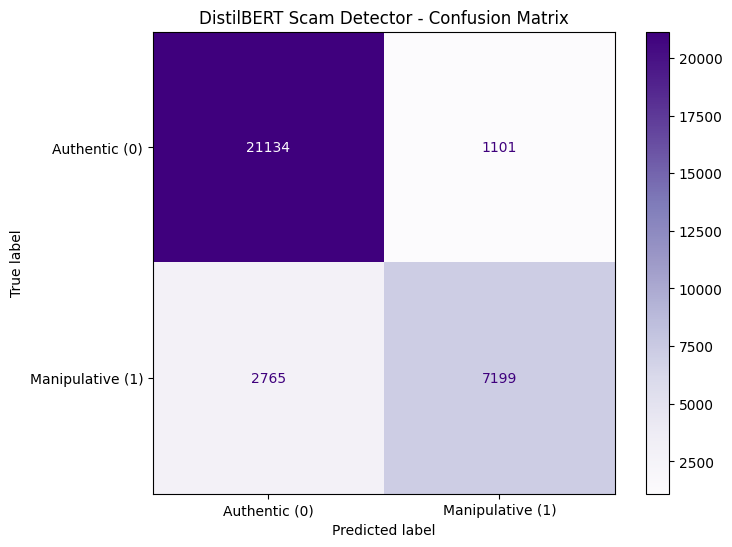

In [ ]:
# =====================================================================
# PHASE 6: DETAILED EVALUATION & VISUALIZATION
# =====================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

print("Generating detailed performance report...")

# 1. Get predictions
predictions_output = trainer.predict(tokenized_test)
preds = np.argmax(predictions_output.predictions, axis=-1)

# 2. Print Classification Report
print("\n--- Detailed Classification Report ---")
target_names = ['Authentic (0)', 'Manipulative (1)']
print(classification_report(y_test, preds, target_names=target_names))

# 3. Plot Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Purples', ax=ax, values_format='d')
plt.title('DistilBERT Scam Detector - Confusion Matrix')
plt.show()

In [ ]:
# =====================================================================
# PHASE 5: CLAIM EXTRACTION MODULE (spaCy + REGEX)
# =====================================================================

import re
import spacy
from spacy.matcher import Matcher

# Load the small English language model from spaCy
nlp = spacy.load("en_core_web_sm")

def extract_suspicious_claims(text):
    doc = nlp(text.lower())
    matcher = Matcher(nlp.vocab)

    detected_claims = []
    risk_keywords = set()

    # 1. Linguistic Pattern Matching via spaCy
    # Pattern A: "Guaranteed/Absolute" + any noun phrase (e.g., "guaranteed returns")
    pattern_guarantee = [
        {"LEMMA": {"IN": ["guarantee", "guaranteed", "risk-free", "absolute", "100%", "assured"]}},
        {"POS": {"IN": ["NOUN", "VERB", "ADJ"]}, "OP": "*"},
        {"LEMMA": {"IN": ["return", "profit", "gain", "money", "income", "payout"]}}
    ]

    # Pattern B: Urgency and Call to Action (e.g., "DM me", "click link")
    pattern_urgency = [
        {"LEMMA": {"IN": ["dm", "text", "click", "join", "buy", "claim"]}},
        {"LOWER": {"IN": ["me", "now", "here", "fast", "today"]}}
    ]

    matcher.add("FINANCIAL_PROMISE", [pattern_guarantee])
    matcher.add("URGENCY_CTA", [pattern_urgency])

    matches = matcher(doc)
    for match_id, start, end in matches:
        string_id = nlp.vocab.strings[match_id]
        span = doc[start:end]
        if string_id == "FINANCIAL_PROMISE":
            detected_claims.append(f"Unrealistic Financial Return Promise: '{span.text.title()}'")
        elif string_id == "URGENCY_CTA":
            detected_claims.append(f"High-Pressure Call-To-Action: '{span.text.title()}'")

    # 2. Statistical Pattern Extraction via Regex
    # Pattern C: Detecting high specific percentages (e.g., 20%, 500% returns)
    percentage_pattern = r'\b(\d{1,4}%|\d{1,4}\s?percent)\b'
    # Pattern D: Large cash dollar promises (e.g., $1000, $5000)
    cash_pattern = r'\$\d{1,7}'

    if re.search(percentage_pattern, text):
        match = re.search(percentage_pattern, text)
        detected_claims.append(f"Specific Yield Target Claimed: '{match.group()}'")
        risk_keywords.add("Yield Tracking")

    if re.search(cash_pattern, text):
        match = re.search(cash_pattern, text)
        detected_claims.append(f"Fixed Cash Reward Promised: '{match.group()}'")
        risk_keywords.add("Cash Bait")

    # 3. Keyword Backup Scan
    scam_keywords = ["free money", "crypto secrets", "get rich", "passive income", "no risk"]
    for word in scam_keywords:
        if word in text.lower():
            detected_claims.append(f"High-Risk Buzzword: '{word.title()}'")

    # Clean duplicates while keeping order
    seen = set()
    unique_claims = [x for x in detected_claims if not (x in seen or seen.add(x))]

    return unique_claims

# =====================================================================
# LIVE PIPELINE INTEGRATION TEST
# =====================================================================

test_sentences = [
    "Guaranteed 20% monthly returns on crypto trading. No risk involved, DM me!",
    "FREE MONEY: Claim your $1000 gift card now!",
    "Stock market hits record high amid economic recovery"
]

print("--- Running Phase 5 Claim Extraction Test ---")
for text in test_sentences:
    print(f"\nText Input: \"{text}\"")
    claims = extract_suspicious_claims(text)
    if claims:
        print("🚨 Extracted Claims Detected:")
        for claim in claims:
            print(f"  -> {claim}")
    else:
        print("✅ No explicit high-risk linguistic claims extracted.")

--- Running Phase 5 Claim Extraction Test ---

Text Input: "Guaranteed 20% monthly returns on crypto trading. No risk involved, DM me!"
🚨 Extracted Claims Detected:
  -> High-Pressure Call-To-Action: 'Dm Me'
  -> High-Risk Buzzword: 'No Risk'

Text Input: "FREE MONEY: Claim your $1000 gift card now!"
🚨 Extracted Claims Detected:
  -> Fixed Cash Reward Promised: '$1000'
  -> High-Risk Buzzword: 'Free Money'

Text Input: "Stock market hits record high amid economic recovery"
✅ No explicit high-risk linguistic claims extracted.


In [ ]:
# =====================================================================
# INTEGRATION TEST: DISTILBERT + SPACEY CLAIM EXTRACTION PIPELINE
# =====================================================================

import os
import re
import torch
import numpy as np
import spacy
from spacy.matcher import Matcher
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# --- SECTION 1: INITIALIZE COMPONENTS ---
print("Initializing end-to-end pipeline components...")

# 1. Load spaCy model for Claim Extraction
nlp = spacy.load("en_core_web_sm")

# 2. Path to your fine-tuned DistilBERT model on Drive
MODEL_PATH = "/content/drive/MyDrive/DSProjectDatasets/best_distilbert_model"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Could not locate your saved model at {MODEL_PATH}. Make sure Phase 4 saving step completed successfully.")

# 3. Load deep learning model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

# Route to GPU if available for fast evaluation
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()
print(f"✅ AI brain loaded successfully on device: '{device}'\n")


# --- SECTION 2: CLAIM EXTRACTION ENGINE ---
def extract_suspicious_claims(text):
    doc = nlp(text.lower())
    matcher = Matcher(nlp.vocab)
    detected_claims = []

    # Pattern A: Absolute Financial Assurances
    pattern_guarantee = [
        {"LEMMA": {"IN": ["guarantee", "guaranteed", "risk-free", "absolute", "100%", "assured"]}},
        {"POS": {"IN": ["NOUN", "VERB", "ADJ"]}, "OP": "*"},
        {"LEMMA": {"IN": ["return", "profit", "gain", "money", "income", "payout"]}}
    ]
    # Pattern B: Urgency and High Pressure Tactics
    pattern_urgency = [
        {"LEMMA": {"IN": ["dm", "text", "click", "join", "buy", "claim"]}},
        {"LOWER": {"IN": ["me", "now", "here", "fast", "today"]}}
    ]

    matcher.add("FINANCIAL_PROMISE", [pattern_guarantee])
    matcher.add("URGENCY_CTA", [pattern_urgency])

    matches = matcher(doc)
    for match_id, start, end in matches:
        string_id = nlp.vocab.strings[match_id]
        span = doc[start:end]
        if string_id == "FINANCIAL_PROMISE":
            detected_claims.append(f"Unrealistic Return Promise ('{span.text.title()}')")
        elif string_id == "URGENCY_CTA":
            detected_claims.append(f"High-Pressure Action Call ('{span.text.title()}')")

    # Regular expression checks for numbers/dollar bait
    percentage_pattern = r'\b(\d{1,4}%|\d{1,4}\s?percent)\b'
    cash_pattern = r'\$\d{1,7}'

    if re.search(percentage_pattern, text):
        detected_claims.append(f"Specific Percentage Yield Tracked ('{re.search(percentage_pattern, text).group()}')")
    if re.search(cash_pattern, text):
        detected_claims.append(f"Fixed Cash Bait Target ('{re.search(cash_pattern, text).group()}')")

    # Fallback key phrase check
    scam_keywords = ["free money", "crypto secrets", "get rich", "passive income", "no risk"]
    for word in scam_keywords:
        if word in text.lower():
            detected_claims.append(f"High-Risk Buzzword Entry ('{word.title()}')")

    # Deduplicate matching results
    return list(dict.fromkeys(detected_claims))


# --- SECTION 3: CORE PIPELINE FUNCTION ---
def analyze_social_post(text_input):
    print("-" * 70)
    print(f"📥 TEXT INPUT: \"{text_input}\"")

    # LAYER 1: DistilBERT Classification Inference
    inputs = tokenizer(text_input, truncation=True, padding="max_length", max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    # 0 = Authentic/Neutral, 1 = Manipulative/Deceptive
    manipulative_prob = probabilities[1] * 100

    print(f"🧠 Layer 1 (DistilBERT NLP): {manipulative_prob:.2f}% Manipulative Intent Likelihood")

    # LAYER 2: Rule-Based Feature Extraction
    extracted_claims = extract_suspicious_claims(text_input)

    if extracted_claims:
        print("🚨 Layer 2 (Linguistic Claims): Suspicious Elements Found!")
        for claim in extracted_claims:
            print(f"    ↳ DETECTED: {claim}")
    else:
        print("✅ Layer 2 (Linguistic Claims): No obvious high-risk patterns extracted.")


# --- SECTION 4: LIVE COMPREHENSIVE PIPELINE EXECUTION ---
if __name__ == "__main__":
    # Test cases demonstrating different vulnerabilities and strengths of each system
    sample_posts = [
        "Guaranteed 20% monthly returns on crypto trading. No risk involved, DM me!",
        "FREE MONEY: Claim your $1000 gift card now!",
        "Apple Inc. plans to expand its operational footprint into green energy markets by late next year.",
        "You won't believe how much money this simple side hustle makes you instantly!"
    ]

    print("--- Executing Combined System Verification ---")
    for post in sample_posts:
        analyze_social_post(post)
    print("-" * 70)

Initializing end-to-end pipeline components...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ AI brain loaded successfully on device: 'cuda'

--- Executing Combined System Verification ---
----------------------------------------------------------------------
📥 TEXT INPUT: "Guaranteed 20% monthly returns on crypto trading. No risk involved, DM me!"
🧠 Layer 1 (DistilBERT NLP): 98.50% Manipulative Intent Likelihood
🚨 Layer 2 (Linguistic Claims): Suspicious Elements Found!
    ↳ DETECTED: High-Pressure Action Call ('Dm Me')
    ↳ DETECTED: High-Risk Buzzword Entry ('No Risk')
----------------------------------------------------------------------
📥 TEXT INPUT: "FREE MONEY: Claim your $1000 gift card now!"
🧠 Layer 1 (DistilBERT NLP): 92.18% Manipulative Intent Likelihood
🚨 Layer 2 (Linguistic Claims): Suspicious Elements Found!
    ↳ DETECTED: Fixed Cash Bait Target ('$1000')
    ↳ DETECTED: High-Risk Buzzword Entry ('Free Money')
----------------------------------------------------------------------
📥 TEXT INPUT: "Apple Inc. plans to expand its operational footprint into green en

In [ ]:
# =====================================================================
# TESTING IN-DISTRIBUTION DATA (WHAT DISTILBERT WAS TRAINED TO CATCH)
# =====================================================================

# Using the exact same analyze_social_post function you just set up
in_distribution_samples = [
    # 1. Classic Clickbait Structure (Matches Clickbait Challenge Dataset)
    "10 Shocking Facts About Hollywood Actors That Will Completely Blow Your Mind!",

    # 2. Sensationalist Celebrity Gossip (Matches GossipCop Fake Dataset)
    "Brad Pitt and Jennifer Aniston secretly married in a private island ceremony last night.",

    # 3. Direct Factual Falsehood (Matches FEVER Refutes Dataset)
    "The Roman Empire was founded in the year 2015 by modern politicians.",

    # 4. Standard Neutral Encyclopedia Entry (Matches FEVER Supports Dataset Baseline)
    "The Roman Empire was an ancient civilization centered around the Mediterranean Sea."
]

print("--- Running In-Distribution Data Verification ---")
for post in in_distribution_samples:
    analyze_social_post(post)
print("-" * 70)

--- Running In-Distribution Data Verification ---
----------------------------------------------------------------------
📥 TEXT INPUT: "10 Shocking Facts About Hollywood Actors That Will Completely Blow Your Mind!"
🧠 Layer 1 (DistilBERT NLP): 95.94% Manipulative Intent Likelihood
✅ Layer 2 (Linguistic Claims): No obvious high-risk patterns extracted.
----------------------------------------------------------------------
📥 TEXT INPUT: "Brad Pitt and Jennifer Aniston secretly married in a private island ceremony last night."
🧠 Layer 1 (DistilBERT NLP): 86.40% Manipulative Intent Likelihood
✅ Layer 2 (Linguistic Claims): No obvious high-risk patterns extracted.
----------------------------------------------------------------------
📥 TEXT INPUT: "The Roman Empire was founded in the year 2015 by modern politicians."
🧠 Layer 1 (DistilBERT NLP): 47.64% Manipulative Intent Likelihood
✅ Layer 2 (Linguistic Claims): No obvious high-risk patterns extracted.
---------------------------------------

In [14]:
import os
import re
import json
import torch
import numpy as np
import spacy
from spacy.matcher import Matcher
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import google.generativeai as genai
from google.colab import userdata

print("Initializing the Complete AI Pipeline...")

# --- 1. SETUP LAYERS 1 & 2 (DistilBERT + spaCy) ---
nlp = spacy.load("en_core_web_sm")
MODEL_PATH = "/content/drive/MyDrive/DSProjectDatasets/best_distilbert_model"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Add a check to ensure MODEL_PATH is a valid directory
if not os.path.isdir(MODEL_PATH):
    raise FileNotFoundError(f"MODEL_PATH '{MODEL_PATH}' is not a valid directory. Please ensure the model was saved correctly in Phase 4.")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, local_files_only=True).to(device)
model.eval()

def get_distilbert_score(text):
    inputs = tokenizer(text, truncation=True, padding="max_length", max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    return probabilities[1] * 100  # Return Class 1 (Manipulative) percentage

def extract_suspicious_claims(text):
    doc = nlp(text.lower())
    matcher = Matcher(nlp.vocab)
    claims = []

    pattern_guarantee = [
        {"LEMMA": {"IN": ["guarantee", "guaranteed", "risk-free", "absolute", "100%", "assured", "passive"]}},
        {"OP": "*"},
        {"LEMMA": {"IN": ["return", "profit", "gain", "money", "income", "payout", "yield", "cash"]}}
    ]
    pattern_urgency = [
        {"LEMMA": {"IN": ["dm", "text", "click", "join", "buy", "claim", "invest", "deposit"]}},
        {"LOWER": {"IN": ["me", "now", "here", "fast", "today", "urgently"]}}
    ]

    matcher.add("PROMISE", [pattern_guarantee])
    matcher.add("URGENCY", [pattern_urgency])

    for match_id, start, end in matcher(doc):
        string_id = nlp.vocab.strings[match_id]
        if string_id == "PROMISE": claims.append(f"Unrealistic Return Promise: '{doc[start:end].text}'")
        elif string_id == "URGENCY": claims.append(f"High-Pressure Action: '{doc[start:end].text}'")

    match_percent = re.search(r'\b\d{1,4}%\s*|\b\d{1,4}\s?percent\b', text, re.IGNORECASE)
    if match_percent:
        claims.append(f"Specific Yield Target: '{match_percent.group().strip()}'")

    match_cash = re.search(r'\$\d{1,7}', text)
    if match_cash:
        claims.append(f"Cash Bait Target: '{match_cash.group()}'")

    for word in ["free money", "crypto secrets", "get rich", "passive income", "no risk"]:
        if word in text.lower(): claims.append(f"High-Risk Buzzword: '{word.title()}'")

    return list(dict.fromkeys(claims))

# --- 2. SETUP LAYER 3 (Gemini Verification API) ---
try:
    genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
    gemini_model = genai.GenerativeModel('gemini-2.5-flash')
except Exception as e:
    print("⚠️ Warning: Gemini API key not found or invalid.")

def verify_with_gemini(text, claims):
    prompt = f"""
    You are a financial fraud investigator. Analyze this text and its extracted claims.
    Text: "{text}"
    Claims: {claims}
    Respond STRICTLY in JSON format without markdown:
    {{"gemini_risk_score": <integer 0-100>, "explanation": "<One clear sentence explaining why it is safe or fraudulent>"}}
    """
    try:
        response = gemini_model.generate_content(prompt, generation_config={"response_mime_type": "application/json"})
        return json.loads(response.text.strip())
    except Exception:
        return {"gemini_risk_score": 50 if claims else 0, "explanation": "API verification failed."}

# --- 3. PHASE 7: RISK SCORING ENGINE ---
def generate_final_report(text):
    print(f"\n" + "="*60)
    print(f"🔍 ANALYZING: \"{text}\" ")
    print("="*60)

    # Run Layers
    nlp_score = get_distilbert_score(text)
    extracted_claims = extract_suspicious_claims(text)
    gemini_data = verify_with_gemini(text, extracted_claims)
    gemini_score = gemini_data["gemini_risk_score"]

    # Calculate Final Score: (70% DistilBERT + 30% Gemini)
    final_score = (0.70 * nlp_score) + (0.30 * gemini_score)

    # Determine Risk Tier
    if final_score <= 30: risk_tier = "🟢 LOW RISK"
    elif final_score <= 70: risk_tier = "🟡 MEDIUM RISK"
    else: risk_tier = "🔴 HIGH RISK"

    # Output the Report (This matches what your UI will show)
    print(f"🧠 Layer 1 (NLP Probability): {nlp_score:.1f}%")
    print(f"🚨 Layer 2 (Extracted Claims): {len(extracted_claims)} found")
    for c in extracted_claims: print(f"   ↳ {c}")
    print(f"🤖 Layer 3 (Gemini Verification): {gemini_score}%")
    print(f"   ↳ Reason: {gemini_data['explanation']}")
    print("-" * 60)
    print(f"🏆 FINAL SYSTEM SCORE: {final_score:.1f}/100 — {risk_tier}")
    print("="*60)

# --- 4. RUN THE SYSTEM ---
if __name__ == "__main__":
    test_cases = [
        "Guaranteed 20% monthly returns on crypto trading. No risk involved, DM me!",
        "Apple Inc. plans to expand its operational footprint into green energy markets by late next year.",
        "Sign up today and get a $5000 guaranteed passive income stream working from home!"
    ]
    for text in test_cases:
        generate_final_report(text)


Initializing the Complete AI Pipeline...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


🔍 ANALYZING: "Guaranteed 20% monthly returns on crypto trading. No risk involved, DM me!" 
🧠 Layer 1 (NLP Probability): 98.5%
🚨 Layer 2 (Extracted Claims): 4 found
   ↳ Unrealistic Return Promise: 'guaranteed 20% monthly returns'
   ↳ High-Pressure Action: 'dm me'
   ↳ Specific Yield Target: '20%'
   ↳ High-Risk Buzzword: 'No Risk'
🤖 Layer 3 (Gemini Verification): 100%
   ↳ Reason: The advertisement displays multiple severe fraud indicators, including an unrealistic guarantee of high monthly returns (20%) combined with a false claim of no risk, which are common red flags for investment scams.
------------------------------------------------------------
🏆 FINAL SYSTEM SCORE: 99.0/100 — 🔴 HIGH RISK

🔍 ANALYZING: "Apple Inc. plans to expand its operational footprint into green energy markets by late next year." 
🧠 Layer 1 (NLP Probability): 2.2%
🚨 Layer 2 (Extracted Claims): 0 found
🤖 Layer 3 (Gemini Verification): 5%
   ↳ Reason: The statement describes a legitimate company's future bus

In [15]:
import os
import re
import json
import torch
import numpy as np
import spacy
from spacy.matcher import Matcher
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import google.generativeai as genai
import streamlit as st

# --- PAGE CONFIGURATION ---
st.set_page_config(page_title="AI Scam Detector", page_icon="🛡️", layout="wide")
st.title("🛡️ Financial Influencer Scam Detection System")
st.markdown("Powered by **DistilBERT**, **spaCy**, and **Gemini 1.5 Flash**.")

# --- CACHE MODELS TO PREVENT RELOADING ON EVERY BUTTON CLICK ---
@st.cache_resource
def load_ai_models():
    # 1. Load spaCy
    nlp = spacy.load("en_core_web_sm")

    # 2. Load DistilBERT (Make sure this path points to where your model folder is in your cloud deployment)
    MODEL_PATH = "./best_distilbert_model"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
    model.eval()

    return nlp, tokenizer, model, device

nlp, tokenizer, model, device = load_ai_models()

# --- GEMINI AUTHENTICATION ---
# Hugging Face Spaces injects secrets as environment variables
gemini_key = os.environ.get("GEMINI_API_KEY")
if gemini_key:
    genai.configure(api_key=gemini_key)
    gemini_model = genai.GenerativeModel('gemini-1.5-flash')
else:
    st.warning("⚠️ Gemini API Key not found in environment variables.")

# --- CORE FUNCTIONS (From your pipeline script) ---
def get_distilbert_score(text):
    inputs = tokenizer(text, truncation=True, padding="max_length", max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    return probabilities[1] * 100

def extract_suspicious_claims(text):
    doc = nlp(text.lower())
    matcher = Matcher(nlp.vocab)
    claims = []

    pattern_guarantee = [{"LEMMA": {"IN": ["guarantee", "guaranteed", "risk-free", "absolute", "100%", "assured", "passive"]}}, {"OP": "*"}, {"LEMMA": {"IN": ["return", "profit", "gain", "money", "income", "payout", "yield", "cash"]}}]
    pattern_urgency = [{"LEMMA": {"IN": ["dm", "text", "click", "join", "buy", "claim", "invest", "deposit"]}}, {"LOWER": {"IN": ["me", "now", "here", "fast", "today", "urgently"]}}]

    matcher.add("PROMISE", [pattern_guarantee])
    matcher.add("URGENCY", [pattern_urgency])

    for match_id, start, end in matcher(doc):
        string_id = nlp.vocab.strings[match_id]
        if string_id == "PROMISE": claims.append(f"Unrealistic Return: '{doc[start:end].text}'")
        elif string_id == "URGENCY": claims.append(f"High-Pressure Action: '{doc[start:end].text}'")

    if re.search(r'\b\d{1,4}%\s*|\b\d{1,4}\s?percent\b', text, re.IGNORECASE): claims.append(f"Specific Yield Target: '{re.search(r'\\b\\d{1,4}%\\s*|\\b\\d{1,4}\\s?percent\\b', text, re.IGNORECASE).group().strip()}'")
    if re.search(r'\$\d{1,7}', text): claims.append(f"Cash Bait Target: '{re.search(r'\\$\\d{1,7}', text).group()}'")
    for word in ["free money", "crypto secrets", "get rich", "passive income", "no risk"]:
        if word in text.lower(): claims.append(f"High-Risk Buzzword: '{word.title()}'")

    return list(dict.fromkeys(claims))

def verify_with_gemini(text, claims):
    if not gemini_key: return {"gemini_risk_score": 50, "explanation": "API verification disabled."}
    prompt = f"You are a financial fraud investigator. Analyze this text and its extracted claims.\nText: '{text}'\nClaims: {claims}\nRespond STRICTLY in JSON format without markdown:\n{{\"gemini_risk_score\": <integer 0-100>, \"explanation\": \"<One clear sentence explaining why it is safe or fraudulent>\"}}"
    try:
        response = gemini_model.generate_content(prompt, generation_config={"response_mime_type": "application/json"})
        return json.loads(response.text.strip())
    except Exception:
        return {"gemini_risk_score": 50, "explanation": "API verification failed."}

# --- UI LAYOUT ---
st.write("Enter a social media caption or financial advertisement below to analyze its deception risk.")
user_input = st.text_area("Social Media Text:", height=100, placeholder="E.g., Guaranteed 20% monthly returns on crypto trading. DM me!")

if st.button("🔍 Analyze Text"):
    if not user_input.strip():
        st.error("Please enter some text to analyze.")
    else:
        with st.spinner("Analyzing linguistic patterns and verifying claims..."):
            # Run Pipeline
            nlp_score = get_distilbert_score(user_input)
            extracted_claims = extract_suspicious_claims(user_input)
            gemini_data = verify_with_gemini(user_input, extracted_claims)
            gemini_score = gemini_data.get("gemini_risk_score", 0)

            # Final Math
            final_score = (0.70 * nlp_score) + (0.30 * gemini_score)

            # --- DISPLAY RESULTS ---
            st.markdown("---")
            st.subheader("System Architecture Output")

            # Top Level Metrics
            col1, col2, col3 = st.columns(3)
            col1.metric("Layer 1: NLP Intent", f"{nlp_score:.1f}%")
            col2.metric("Layer 2: Claims Extracted", len(extracted_claims))
            col3.metric("Layer 3: Gemini Factual Risk", f"{gemini_score}%")

            # Explainable AI Section
            st.markdown("### 🤖 Factual Reasoning (Gemini)")
            st.info(gemini_data.get("explanation", "No reasoning provided."))

            if extracted_claims:
                st.markdown("### 🚨 Extracted Linguistic Evidence (spaCy)")
                for claim in extracted_claims:
                    st.warning(f"↳ {claim}")

            # Final Risk Score Header
            st.markdown("---")
            if final_score <= 30:
                st.success(f"🟢 LOW RISK | Final Score: {final_score:.1f}/100")
            elif final_score <= 70:
                st.warning(f"🟡 MEDIUM RISK | Final Score: {final_score:.1f}/100")
            else:
                st.error(f"🔴 HIGH RISK | Final Score: {final_score:.1f}/100")

            st.progress(int(final_score))

ModuleNotFoundError: No module named 'streamlit'